# Data Exploration

## I. Tổng quan về dữ liệu thô

### 1. Tải thư viện & đọc file

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


In [2]:
path = "../data/amazon_crawl/amazon_products_US_20260324_231228.csv"
try:
    df = pd.read_csv(path)
    print("[SUCCESS]: Loading dataset successful")
except Exception as e:
    print(f"[ERROR]: Loading dataset fail: {e}")

[SUCCESS]: Loading dataset successful


### 2. Thông tin cơ bản

In [3]:
df.head()

,asin,title,price,original_price,rating,reviews,currency,is_best_seller,is_amazon_choice,is_prime,...,video_thumbnail,has_video,key_features,full_description,technical_details,product_details,has_aplus_content,aplus_images,has_brand_story,frequently_bought_together
0,B08NHSPCR6,HP Chromebook 11A G8 Education Edition AMD A4-...,NaN,NaN,4.1,1161,NaN,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B0GR6F8HXV,Apple 2026 MacBook Neo 13-inch Laptop with A18...,749.00,NaN,4.8,73,USD,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,B0D7NVS6RV,"Lenovo Yoga 7i 2-in-1 Laptop, 16&quot; 2K Touc...",799.99,NaN,4.5,167,USD,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,B08H5878D3,LEXiBOOK Spider-Man - Educational and Bilingua...,49.99,NaN,4.2,1355,USD,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,B0791H74NT,Creative Pebble 2.0 USB-Powered Desktop Speake...,23.74,24.99,4.5,67192,USD,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 2.1. Kích thước dữ liệu

In [4]:
print(f"Data shape: {df.shape}")

num_rows, num_columns = df.shape
print(f"Amount of rows is: {num_rows}")
print(f"Amount of columns is: {num_columns}")

Data shape: (9180, 58)
Amount of rows is: 9180
Amount of columns is: 58


#### 2.2. Kiểu dữ liệu và ý nghĩa của các đặc trưng

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9180 entries, 0 to 9179
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   asin                        9180 non-null   object 
 1   title                       9180 non-null   object 
 2   price                       8910 non-null   float64
 3   original_price              4096 non-null   float64
 4   rating                      9157 non-null   float64
 5   reviews                     9180 non-null   int64  
 6   currency                    8939 non-null   object 
 7   is_best_seller              9180 non-null   bool   
 8   is_amazon_choice            9180 non-null   bool   
 9   is_prime                    9180 non-null   bool   
 10  sales_volume                8308 non-null   object 
 11  main_category               9180 non-null   object 
 12  category_hierarchy          9180 non-null   object 
 13  crawl_category              9180 

| STT | Feature | Đơn vị | Ý nghĩa |
|-----|--------|-------|--------|
| 1 | asin | Không có | Mã định danh duy nhất của sản phẩm trên Amazon (ASIN). |
| 2 | title | Không có | Tiêu đề sản phẩm hiển thị trên Amazon, chứa thông tin mô tả chính. |
| 3 | price | USD ($) | Giá hiện tại của sản phẩm tại thời điểm crawl. |
| 4 | original_price | USD ($) | Giá gốc trước khi giảm giá (nếu có). |
| 5 | rating | Điểm (0–5) | Điểm đánh giá trung bình từ người dùng. |
| 6 | reviews | Số lượng | Tổng số lượt đánh giá (reviews) của sản phẩm. |
| 7 | currency | Không có | Đơn vị tiền tệ (ví dụ: USD). |
| 8 | is_best_seller | Boolean | Sản phẩm có thuộc danh sách Best Seller hay không. |
| 9 | is_amazon_choice | Boolean | Sản phẩm có được gắn nhãn “Amazon’s Choice” hay không. |
| 10 | is_prime | Boolean | Sản phẩm có hỗ trợ Amazon Prime hay không. |
| 11 | sales_volume | Không có | Số lượng bán ra (thường dạng text như “500+ bought”). |
| 12 | main_category | Không có | Danh mục chính của sản phẩm (ví dụ: electronics). |
| 13 | category_hierarchy | Không có | Cấu trúc phân cấp danh mục (dạng list hoặc JSON). |
| 14 | crawl_category | Không có | Danh mục dùng khi crawl dữ liệu. |
| 15 | link | URL | Đường dẫn đến trang sản phẩm. |
| 16 | image_url | URL | Đường dẫn đến ảnh chính của sản phẩm. |
| 17 | delivery_info | Không có | Thông tin giao hàng (thời gian, phí, khu vực). |
| 18 | number_of_offers | Số lượng | Số người bán cung cấp sản phẩm. |
| 19 | lowest_offer_price | USD ($) | Giá thấp nhất trong các offer. |
| 20 | has_variations | Boolean | Sản phẩm có nhiều biến thể hay không. |
| 21 | is_climate_friendly | Boolean | Sản phẩm có thân thiện môi trường hay không. |
| 22 | variation_dimensions | Không có | Các chiều biến thể (màu, size, cấu hình...). |
| 23 | variants | Không có | Thông tin các biến thể hiện tại. |
| 24 | all_variants | Không có | Danh sách toàn bộ biến thể của sản phẩm. |
| 25 | top_reviews | Không có | Các đánh giá nổi bật của sản phẩm. |
| 26 | detailed_rating | Không có | Phân bố rating chi tiết (5 sao, 4 sao...). |
| 27 | current_price | USD ($) | Giá hiện tại (có thể trùng với price). |
| 28 | product_name | Không có | Tên rút gọn của sản phẩm. |
| 29 | slug | Không có | Chuỗi định danh URL thân thiện (SEO). |
| 30 | parent_asin | Không có | ASIN của sản phẩm cha (nếu là biến thể). |
| 31 | landing_asin | Không có | ASIN trang landing chính. |
| 32 | brand_info | Không có | Thông tin thương hiệu. |
| 33 | brand_url | URL | Đường dẫn tới trang thương hiệu. |
| 34 | brand_urls | URL | Danh sách các URL liên quan đến brand. |
| 35 | unit_price | USD ($) | Giá trên mỗi đơn vị sản phẩm. |
| 36 | unit_count | Số lượng | Số lượng đơn vị trong sản phẩm. |
| 37 | min_order_quantity | Số lượng | Số lượng tối thiểu cần mua (hiện tại null). |
| 38 | country | Không có | Quốc gia bán hoặc phân phối sản phẩm. |
| 39 | availability | Không có | Tình trạng còn hàng. |
| 40 | condition | Không có | Tình trạng sản phẩm (new, used...). |
| 41 | estimated_delivery_date | Ngày | Ngày giao hàng dự kiến. |
| 42 | customer_feedback_summary | Không có | Tổng hợp phản hồi khách hàng (hiện null). |
| 43 | top_reviews_global | Không có | Review nổi bật toàn cầu. |
| 44 | is_bestseller | Không có | Cờ bestseller (phiên bản khác của is_best_seller). |
| 45 | main_image_url | URL | URL ảnh chính chi tiết. |
| 46 | additional_image_urls | URL | Danh sách ảnh bổ sung. |
| 47 | product_videos | Không có | Video chính thức của sản phẩm. |
| 48 | user_videos | Không có | Video do người dùng đăng. |
| 49 | video_thumbnail | URL | Ảnh thumbnail của video. |
| 50 | has_video | Boolean | Sản phẩm có video hay không. |
| 51 | key_features | Không có | Các đặc điểm nổi bật (bullet points). |
| 52 | full_description | Không có | Mô tả chi tiết sản phẩm. |
| 53 | technical_details | Không có | Thông số kỹ thuật chi tiết. |
| 54 | product_details | Không có | Thông tin chi tiết bổ sung. |
| 55 | has_aplus_content | Boolean | Có nội dung A+ (Enhanced Brand Content). |
| 56 | aplus_images | URL | Hình ảnh trong nội dung A+. |
| 57 | has_brand_story | Boolean | Có câu chuyện thương hiệu hay không. |
| 58 | frequently_bought_together | Không có | Danh sách sản phẩm thường mua cùng. |

Các biến đang sai định dạng so với ý nghĩa
- sales_volume: đang là object nhưng mang ý nghĩa số lượng (numeric).
- delivery_info: đang là object nhưng thực chất là dữ liệu tổng hợp nhiều thuộc tính.

### 3. Kiểm tra dòng trùng lặp

In [6]:
duplicated_rows = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicated_rows}")

Number of duplicated rows: 382


Có 382 dòng trùng lặp, sẽ tiến hành xóa các dòng trùng lặp này.

### 4. Kiểm tra dữ liệu thiếu

Khi quan sát dữ liệu ban đầu, có thể thấy nhiều cột xuất hiện các giá trị như [], {} hoặc chuỗi rỗng. Điều này có thể làm sai lệch kết quả khi phân tích. Vì vậy, trước tiên cần chuyển các giá trị này về dạng NaN để thống nhất cách biểu diễn dữ liệu thiếu. Sau khi thực hiện bước này, tiến hành kiểm tra tỷ lệ missing của từng feature để hiểu rõ mức độ thiếu dữ liệu.

In [7]:
df = df.replace(["[]", "{}", ""], np.nan)
zero_missing_cols = 0
list_missing_values = []

for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percentage = (missing_count / df.shape[0]) * 100
    list_missing_values.append({
        "Feature": col,
        "Missing": missing_count,
        "Percentage": f"{missing_percentage:.2f}%"
    })
    if missing_percentage > 85:
        zero_missing_cols += 1

df_missing_values = pd.DataFrame(list_missing_values)
df_missing_values = df_missing_values.sort_values(by="Missing", ascending=False)
print(df_missing_values)

print(f"Number of columns with more than 85% missing values: {zero_missing_cols}")

                       Feature  Missing Percentage
36          min_order_quantity     9180    100.00%
41   customer_feedback_summary     9180    100.00%
47                 user_videos     9180    100.00%
34                  unit_price     8915     97.11%
35                  unit_count     8915     97.11%
39                   condition     8891     96.85%
57  frequently_bought_together     8781     95.65%
51            full_description     8694     94.71%
46              product_videos     8331     90.75%
22                    variants     8291     90.32%
48             video_thumbnail     8288     90.28%
42          top_reviews_global     8260     89.98%
50                key_features     8208     89.41%
40     estimated_delivery_date     8208     89.41%
28                        slug     8196     89.28%
23                all_variants     8194     89.26%
21        variation_dimensions     8193     89.25%
29                 parent_asin     8193     89.25%
38                availability 

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13416\3599579145.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(["[]", "{}", ""], np.nan)


In [8]:
def plot_missing_values(df):
    import matplotlib.pyplot as plt
    import seaborn as sns

    plt.figure(figsize=(14, 10))
    sns.set_theme(style="whitegrid")

    # Convert % string → float nếu cần
    if df["Percentage"].dtype == object:
        df["Percentage"] = df["Percentage"].str.replace("%", "").astype(float)

    # Sort giảm dần cho dễ nhìn
    df = df.sort_values(by="Percentage", ascending=False)

    # Plot
    ax = sns.barplot(
        x="Percentage",
        y="Feature",
        data=df,
        palette="Reds_r",
        hue="Feature"
    )

    # Title & label
    plt.title("Tỷ lệ Khuyết thiếu Dữ liệu theo Đặc trưng",
              fontsize=16, fontweight="bold", pad=20)
    plt.xlabel("Tỷ lệ khuyết thiếu (%)", fontsize=12, fontweight="bold")
    plt.ylabel("Tên đặc trưng", fontsize=12, fontweight="bold")

    # Hiển thị value trên thanh
    for p in ax.patches:
        width = p.get_width()
        ax.text(width + 1, p.get_y() + p.get_height()/2,
                f"{width:.2f}%",
                va="center", fontsize=10, fontweight="bold")

    # Scale hợp lý
    plt.xlim(0, 100)

    plt.tight_layout()
    plt.show()

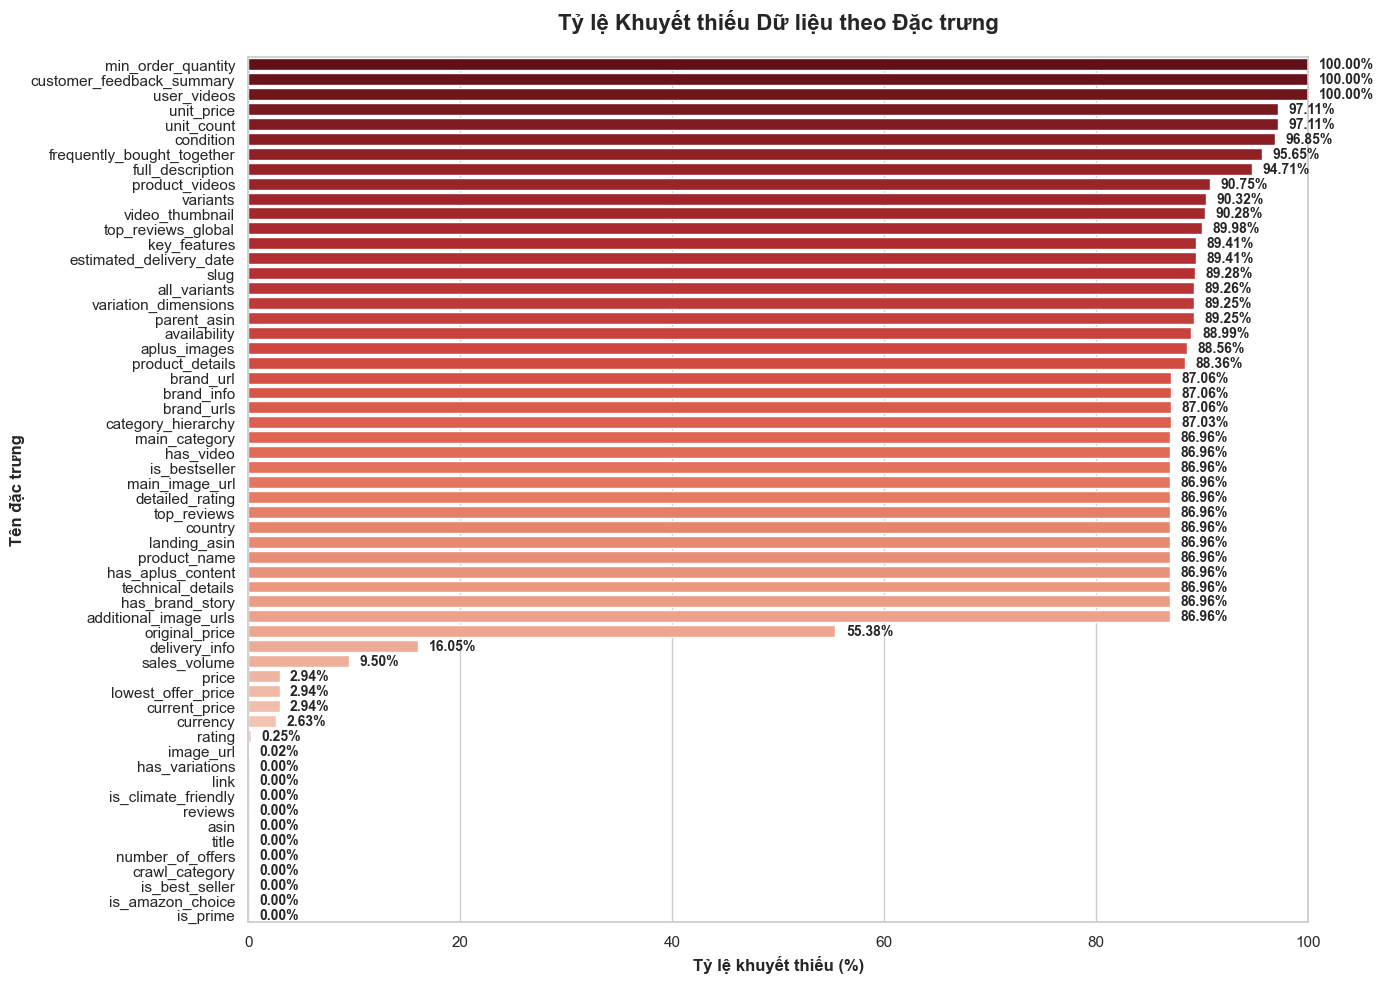

In [9]:
plot_missing_values(df_missing_values)

Dựa trên kết quả đã phân tích, có tới 38 feature có tỷ lệ missing vượt quá 85%. Với mức độ thiếu dữ liệu quá lớn như vậy, các feature này không còn mang nhiều ý nghĩa trong việc phân tích hay xây dựng mô hình.

## II. Tổng quan về dữ liệu đã xử lý

### 1. Đọc file

In [10]:
path = "../data/Processed/amazon_products_viz.csv"
try:
    df_processed = pd.read_csv(path)
    print("[SUCCESS]: Loading dataset successful")
except Exception as e:
    print(f"[ERROR]: Loading dataset fail: {e}")

[SUCCESS]: Loading dataset successful


### 2. Thông tin cơ bản

#### 2.1 Kích thước dữ liệu

In [11]:
print(f"Data shape: {df_processed.shape}")

num_rows, num_columns = df_processed.shape
print(f"Amount of rows is: {num_rows}")
print(f"Amount of columns is: {num_columns}")

Data shape: (8176, 63)
Amount of rows is: 8176
Amount of columns is: 63


#### 2.2. Kiểu dữ liệu và ý nghĩa của các đặc trưng

In [12]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8176 entries, 0 to 8175
Data columns (total 63 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   asin                        8176 non-null   object 
 1   title                       8176 non-null   object 
 2   price                       8176 non-null   float64
 3   original_price              8176 non-null   float64
 4   rating                      8176 non-null   float64
 5   reviews                     8176 non-null   int64  
 6   currency                    8176 non-null   object 
 7   is_best_seller              8176 non-null   bool   
 8   is_amazon_choice            8176 non-null   bool   
 9   is_prime                    8176 non-null   bool   
 10  sales_volume                8176 non-null   object 
 11  main_category               1017 non-null   object 
 12  category_hierarchy          1012 non-null   object 
 13  crawl_category              8176 

### 3. Kiểm tra dòng trùng lặp

In [13]:
duplicated_rows = df_processed.duplicated().sum()
print(f"Number of duplicated rows: {duplicated_rows}")

Number of duplicated rows: 0


### 4. Kiểm tra dữ liệu thiếu

In [14]:
zero_missing_cols = 0
list_missing_values = []

for col in df_processed.columns:
    missing_count = df_processed[col].isnull().sum()
    missing_percentage = (missing_count / df_processed.shape[0]) * 100
    list_missing_values.append({
        "Feature": col,
        "Missing": missing_count,
        "Percentage": f"{missing_percentage:.2f}%"
    })
    if missing_percentage > 85:
        zero_missing_cols += 1

df_processed_missing_values = pd.DataFrame(list_missing_values)
df_processed_missing_values = df_processed_missing_values.sort_values(by="Missing", ascending=False)
print(df_processed_missing_values)

print(f"Number of columns with more than 85% missing values: {zero_missing_cols}")

                      Feature  Missing Percentage
47                user_videos     8176    100.00%
41  customer_feedback_summary     8176    100.00%
36         min_order_quantity     8176    100.00%
35                 unit_count     7944     97.16%
34                 unit_price     7944     97.16%
..                        ...      ...        ...
8            is_amazon_choice        0      0.00%
10               sales_volume        0      0.00%
9                    is_prime        0      0.00%
58           sales_volume_num        0      0.00%
59               delivery_fee        0      0.00%

[63 rows x 3 columns]
Number of columns with more than 85% missing values: 39


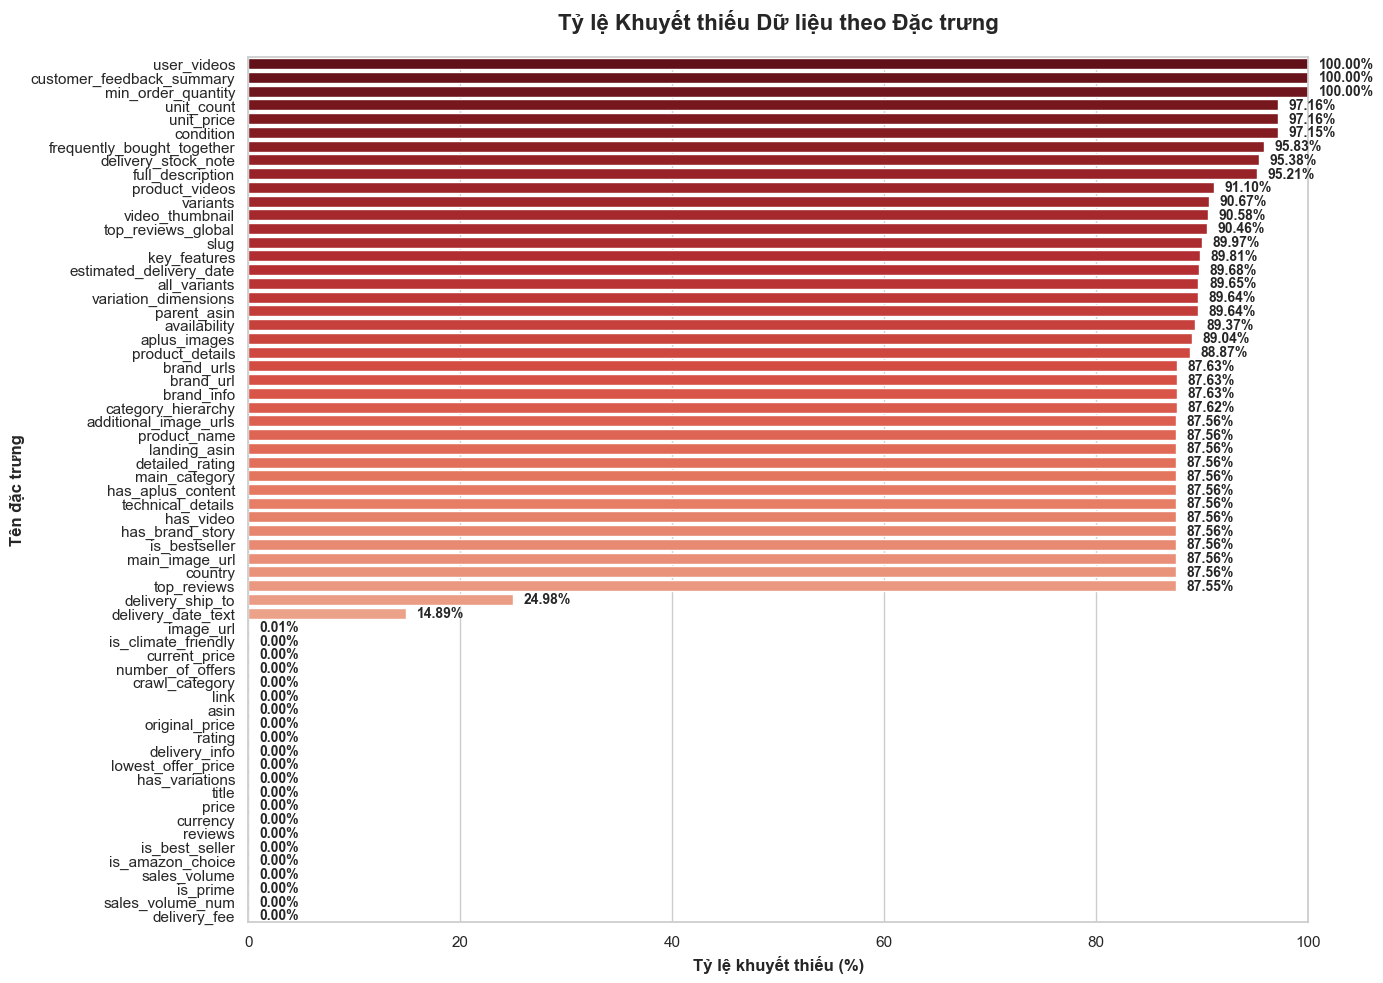

In [15]:
plot_missing_values(df_processed_missing_values)

In [16]:
# threshold = 0.85

# cols_to_drop = [
#     col for col in df_processed.columns
#     if df_processed[col].isnull().mean() > threshold
# ]

# df_processed = df_processed.drop(columns=cols_to_drop)

# print("Các cột đã bị drop:")
# print(cols_to_drop)

# print(f"Số lượng cột bị drop: {len(cols_to_drop)}")

In [17]:
# zero_missing_cols = 0
# list_missing_values = []

# for col in df_processed.columns:
#     missing_count = df_processed[col].isnull().sum()
#     missing_percentage = (missing_count / df_processed.shape[0]) * 100
#     list_missing_values.append({
#         "Feature": col,
#         "Missing": missing_count,
#         "Percentage": f"{missing_percentage:.2f}%"
#     })
#     if missing_percentage > 85:
#         zero_missing_cols += 1

# df_processed_missing_values = pd.DataFrame(list_missing_values)
# df_processed_missing_values = df_processed_missing_values.sort_values(by="Missing", ascending=False)
# print(df_processed_missing_values)

# print(f"Number of columns with more than 85% missing values: {zero_missing_cols}")

In [18]:
# plot_missing_values(df_processed_missing_values)

## III. Phân tích khám phá những Đặc Trưng Quan Trọng

### 1. Phân tích các đặc trưng Numerical

#### 1.1 Trích xuất đặc trưng

In [19]:
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
print(f"There are {len(numeric_cols)} numeric columns.")
print(numeric_cols)

There are 13 numeric columns.
['price', 'original_price', 'rating', 'reviews', 'number_of_offers', 'lowest_offer_price', 'current_price', 'unit_count', 'min_order_quantity', 'customer_feedback_summary', 'user_videos', 'sales_volume_num', 'delivery_fee']


#### 1.2. Giá trị phân phối


In [20]:
numeric_cols_important = ['sales_volume_num', 'price', 'current_price', 'rating', 'reviews', 'original_price', 'lowest_offer_price', 'number_of_offers', 'delivery_fee']
df_processed_important_numeric = df_processed[numeric_cols_important]
df_processed_important_numeric.describe().T

,count,mean,std,min,25%,50%,75%,max
sales_volume_num,8176.0,3744.471624,7729.786188,0.00,200.000,1000.00,5000.00,100000.00
price,8176.0,77.359846,164.537665,0.00,14.205,26.99,69.99,3399.99
current_price,8176.0,77.359163,164.537516,0.00,14.205,26.99,69.99,3399.99
rating,8176.0,4.452043,0.295707,1.00,4.300,4.50,4.60,5.00
reviews,8176.0,9392.863258,22433.495486,1.00,406.000,2160.50,8499.25,659066.00
original_price,8176.0,86.601035,177.195616,0.00,15.990,29.99,84.15,3399.99
lowest_offer_price,8176.0,72.370281,153.787529,0.62,13.990,25.99,69.00,3399.99
number_of_offers,8176.0,2.250856,3.950063,1.00,1.000,1.00,2.00,80.00
delivery_fee,8176.0,25.426575,37.530002,0.00,11.640,14.78,24.39,449.15


**Nhận xét phân phối theo từng đặc trưng**

##### 1. sales_volume_num
- Mean ≈ 3744.47, median (50%) ≈ 1000 → **lệch phải rất mạnh**
- Q1 ≈ 200, Q3 ≈ 5000 → phần lớn sản phẩm có doanh số ở mức thấp đến trung bình
- Max = 100000 >> Q3 → **xuất hiện nhiều outlier rất lớn**
- Min = 0 → có sản phẩm chưa phát sinh doanh số

**Kết luận:** Phân phối lệch phải mạnh, có nhiều outliers lớn

##### 2. price
- Mean ≈ 77.36, median (50%) ≈ 26.99 → **lệch phải mạnh**
- Q1 ≈ 14.21, Q3 ≈ 69.99 → phần lớn sản phẩm thuộc phân khúc giá thấp đến trung bình
- Max = 3399.99 >> Q3 → **có nhiều outlier giá cao**
- Min = 0 → có thể là dữ liệu lỗi hoặc sản phẩm đặc biệt

**Kết luận:** Phân phối lệch phải, nhiều outliers

##### 3. current_price
- Mean ≈ 77.36, median ≈ 26.99 → **gần như giống hoàn toàn với price**
- Q1 ≈ 14.21, Q3 ≈ 69.99
- Max = 3399.99 → có outlier lớn

**Kết luận:** Biến gần như trùng hoàn toàn với `price`

##### 4. rating
- Mean ≈ 4.45, median ≈ 4.5 → **phân phối khá cân đối**
- Q1 ≈ 4.3, Q3 ≈ 4.6 → dữ liệu tập trung cao
- Min = 1, Max = 5 → đúng range đánh giá
- Std ≈ 0.30 → **ít biến động**

**Kết luận:** Đây là feature ổn định nhất, phù hợp để phân tích và modeling

##### 5. reviews
- Mean ≈ 9392.86, median ≈ 2160.5 → **lệch phải rất mạnh**
- Q1 ≈ 406, Q3 ≈ 8499 → đa số sản phẩm có số review thấp hơn rất nhiều so với max
- Max = 659066 → **outlier cực lớn**
- Min = 1 → hầu hết sản phẩm đều có review

**Kết luận:** Phân phối rất skewed

##### 6. original_price
- Mean ≈ 86.60 > median ≈ 29.99 → **lệch phải mạnh**
- Q1 ≈ 15.99, Q3 ≈ 84.15
- Max = 3399.99 → có outlier lớn

**Kết luận:** Phân phối tương tự `price`, có thể dùng để phân tích mức giảm giá (discount)

##### 7. lowest_offer_price
- Mean ≈ 72.37, median ≈ 25.99 → **lệch phải**
- Q1 ≈ 13.99, Q3 ≈ 69.00
- Max = 3399.99 → có outlier lớn

**Kết luận:** Phân phối gần giống `price`, cần kiểm tra tương quan để tránh trùng thông tin

##### 8. number_of_offers
- Mean ≈ 2.25, median = 1 → **đa số chỉ có 1 seller**
- Q1 = 1, Q3 = 2 → phần lớn sản phẩm có rất ít người bán
- Max = 80 → có outlier rõ rệt

**Kết luận:** Feature có ý nghĩa về cạnh tranh thị trường, nhưng cần xử lý outlier

##### 9. delivery_fee
- Mean ≈ 25.43, median ≈ 14.78 → **lệch phải**
- Q1 ≈ 11.64, Q3 ≈ 24.39
- Max = 449.15 → có outlier phí giao hàng rất cao
- Min = 0 → có nhiều sản phẩm miễn phí vận chuyển

**Kết luận:** Feature quan trọng cho phân tích Prime và lợi thế cạnh tranh giao hàng

##### Tổng kết chung
- Hầu hết các biến giá, doanh số và số lượng đều **lệch phải (right-skewed)**
- Nhiều feature xuất hiện **outliers rất lớn**, đặc biệt là `sales_volume_num`, `reviews`, `price`
- Một số biến có khả năng **trùng thông tin cao** như `price` và `current_price`
- `rating` là feature **ổn định và sạch nhất**

In [21]:
palette = sns.color_palette("Set2", len(numeric_cols))
sns.set_style("whitegrid")

def plot_numerical_distribution_and_boxplot(col, i):
    color = palette[i]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    sns.histplot(
        data=df_processed_important_numeric,
        x=col,
        kde=True,
        bins=40,
        ax=axes[0],
        color=color,
        edgecolor="white"
    )
    axes[0].set_title(f'Distribution of {col}', fontsize=13, weight='bold')
    axes[0].set_xlabel(col)

    # Boxplot
    sns.boxplot(
        data=df_processed_important_numeric,
        x=col,
        ax=axes[1],
        color=color,
        width=0.4
    )
    axes[1].set_title(f'Box Plot of {col}', fontsize=13, weight='bold')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

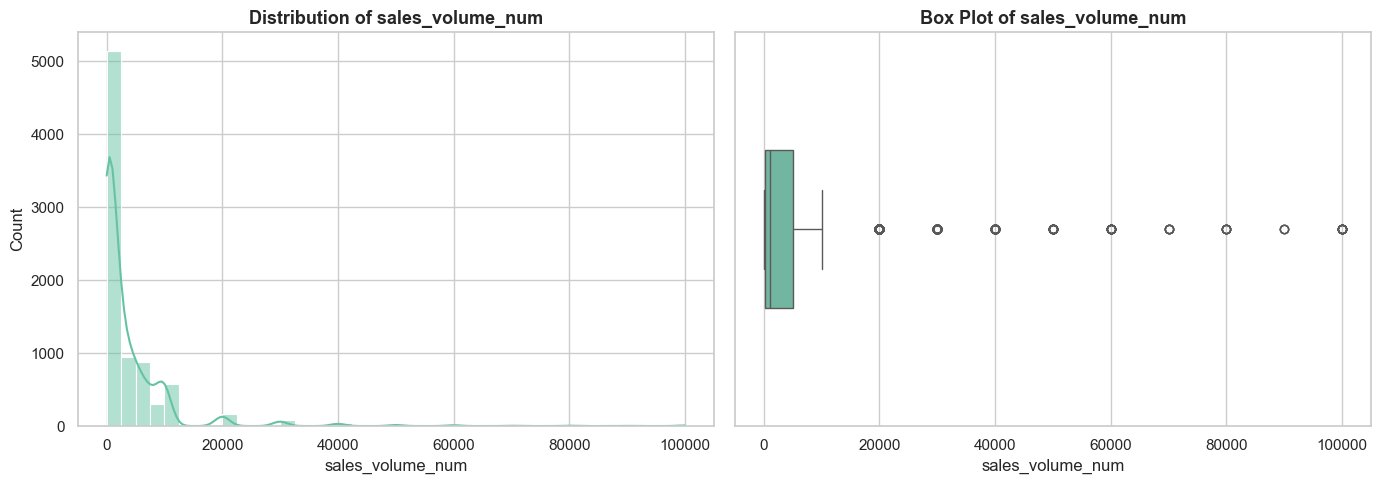

In [22]:
plot_numerical_distribution_and_boxplot(numeric_cols_important[0], 0)

`sales_volume_num`

- Histogram cho thấy dữ liệu tập trung rất mạnh ở vùng giá trị thấp (gần 0 đến khoảng vài nghìn) và giảm nhanh khi giá trị tăng, **phân phối lệch phải rất mạnh**
- Đuôi phân phối kéo dài đến 100000 cho thấy tồn tại một số sản phẩm có doanh số cực cao nhưng rất hiếm gặp
- Boxplot xuất hiện rất nhiều điểm nằm ngoài whisker bên phải, **có nhiều outliers lớn**
- Median nằm thấp hơn nhiều so với mean, xác nhận dữ liệu bị skew mạnh
- Phần lớn sản phẩm có doanh số thấp hoặc trung bình, chỉ một số rất ít sản phẩm bán cực chạy

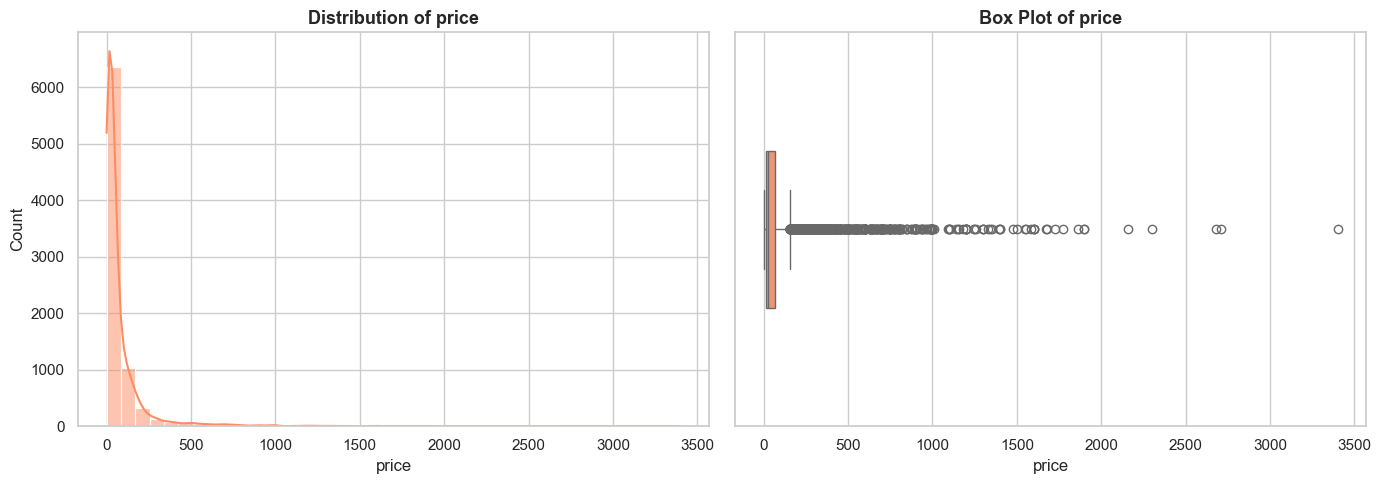

In [23]:
plot_numerical_distribution_and_boxplot(numeric_cols_important[1], 1)

`price`

- Histogram cho thấy dữ liệu tập trung chủ yếu ở vùng giá thấp (khoảng dưới 100 USD) và giảm rất nhanh khi giá tăng, **phân phối lệch phải mạnh**
- Đuôi phân phối kéo dài đến khoảng 3400 cho thấy tồn tại một số sản phẩm có giá rất cao nhưng số lượng rất ít
- Boxplot xuất hiện rất nhiều điểm nằm ngoài whisker bên phải, **có rất nhiều outliers lớn**
- Phần lớn sản phẩm thuộc phân khúc giá thấp đến trung bình, trong khi một số ít sản phẩm thuộc phân khúc cao cấp
- Min = 0 cho thấy có thể tồn tại dữ liệu lỗi, sản phẩm miễn phí hoặc giá chưa được cập nhật đầy đủ

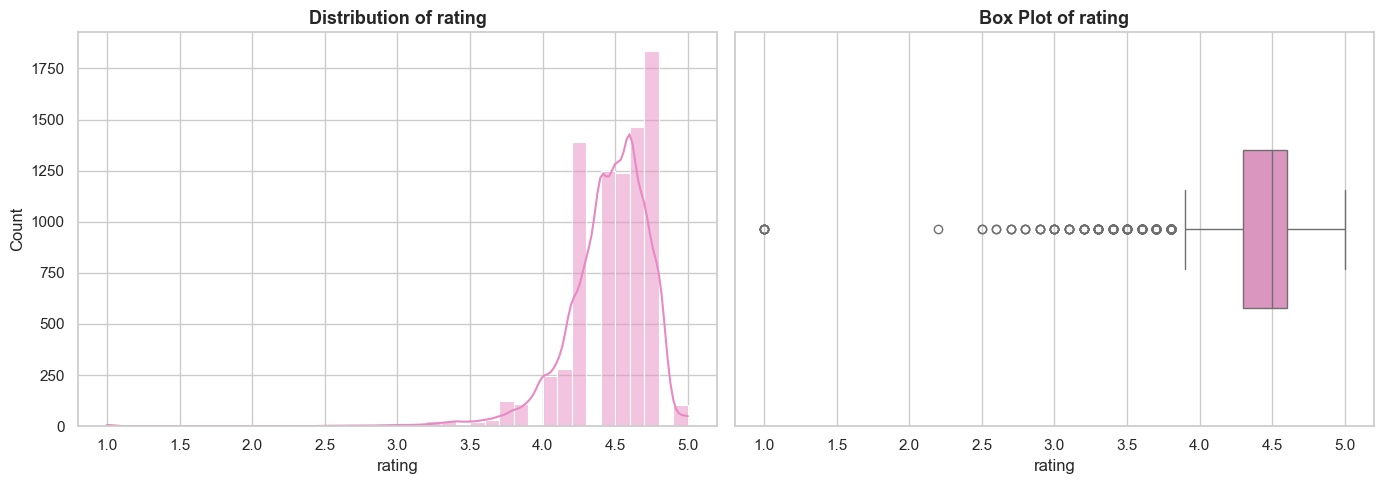

In [24]:
plot_numerical_distribution_and_boxplot(numeric_cols_important[3], 3)

`rating`

- Histogram cho thấy dữ liệu tập trung chủ yếu trong khoảng từ 4.0 đến 4.8, đặc biệt quanh mức 4.4–4.7, cho thấy phần lớn sản phẩm có đánh giá khá cao
- Phân phối tương đối cân đối nhưng hơi lệch trái nhẹ vì phần lớn giá trị nằm gần mức tối đa là 5
- Boxplot cho thấy một số điểm ngoại lệ ở vùng rating thấp như 1.0, 2.2, 2.5…, nhưng số lượng không nhiều
- Khoảng biến thiên nhỏ và hộp boxplot khá gọn chứng tỏ dữ liệu ổn định, ít biến động
- Min = 1 và Max = 5 hoàn toàn phù hợp với thang đo đánh giá của Amazon


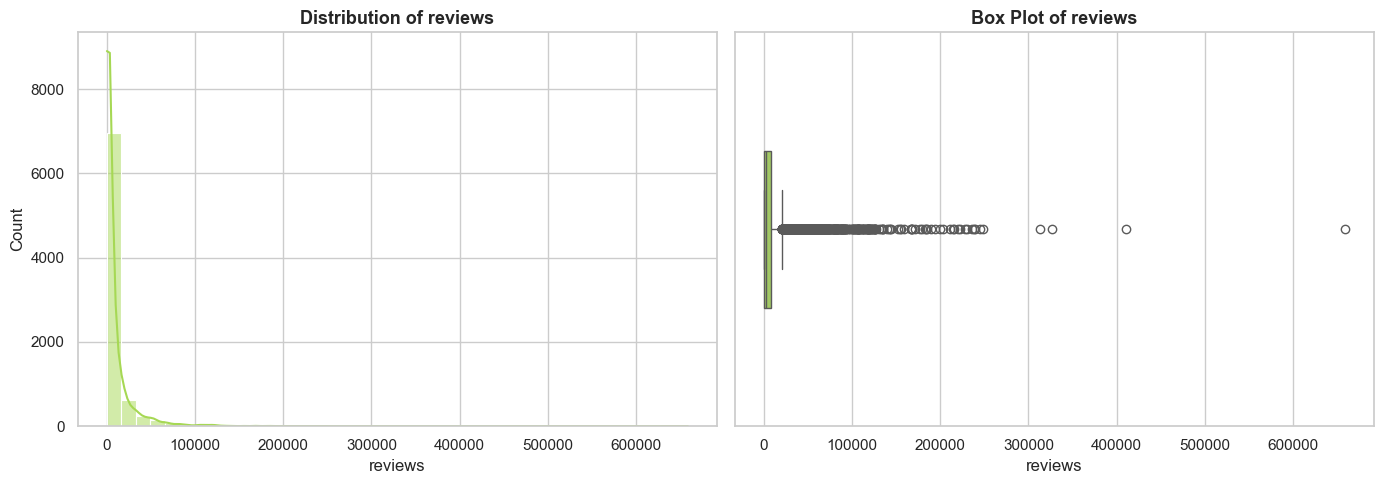

In [25]:
plot_numerical_distribution_and_boxplot(numeric_cols_important[4], 4)

`reviews`

- Histogram cho thấy dữ liệu tập trung rất mạnh ở vùng số review thấp, chủ yếu dưới vài nghìn review, và giảm rất nhanh khi số review tăng lên
- Phân phối lệch phải rất mạnh vì tồn tại một số sản phẩm có lượng review cực lớn trong khi phần lớn sản phẩm chỉ có ít review
- Đuôi phân phối kéo dài đến hơn 650000 cho thấy sự chênh lệch rất lớn giữa các sản phẩm phổ thông và các sản phẩm cực kỳ phổ biến
- Boxplot xuất hiện rất nhiều điểm nằm ngoài whisker bên phải, chứng tỏ có rất nhiều outliers lớn

### 2. Phân tích các đặc trưng Categorical

#### 2.1. Trích xuất đặc trưng

In [26]:
categorical_cols = df_processed.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"There are {len(categorical_cols)} categorical columns.")
print(categorical_cols)

There are 45 categorical columns.
['asin', 'title', 'currency', 'sales_volume', 'main_category', 'category_hierarchy', 'crawl_category', 'link', 'image_url', 'delivery_info', 'variation_dimensions', 'variants', 'all_variants', 'top_reviews', 'detailed_rating', 'product_name', 'slug', 'parent_asin', 'landing_asin', 'brand_info', 'brand_url', 'brand_urls', 'unit_price', 'country', 'availability', 'condition', 'estimated_delivery_date', 'top_reviews_global', 'is_bestseller', 'main_image_url', 'additional_image_urls', 'product_videos', 'video_thumbnail', 'has_video', 'key_features', 'full_description', 'technical_details', 'product_details', 'has_aplus_content', 'aplus_images', 'has_brand_story', 'frequently_bought_together', 'delivery_date_text', 'delivery_ship_to', 'delivery_stock_note']


In [27]:
categorical_cols_important = [
    'crawl_category',
]

#### 2.2. Giá trị phân phối

In [28]:
def plot_categorical_distribution(col_count, col_name, top_n=5):
    top_vals = col_count.nlargest(top_n).index
    top_counts = col_count.nlargest(top_n).values

    plt.figure(figsize=(12, 5))
    sns.barplot(x=top_counts, y=top_vals, hue=top_vals, palette="viridis", legend=False)
    plt.title(f'Most Frequent {col_name}', fontsize=15)
    plt.xlabel('Number of Appearances', fontsize=12)
    plt.ylabel(col_name, fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

There are 30 unique values in crawl_category column.
Most frequent crawl_category values is: home_air_quality with 303 appearances.


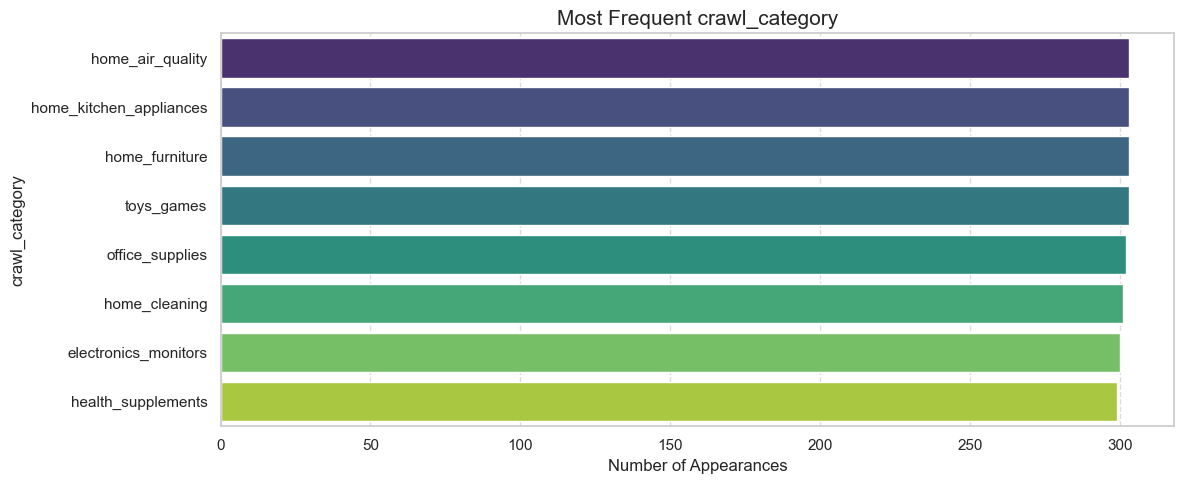

In [29]:

unique = df_processed[categorical_cols_important[0]].nunique()
counts = df_processed[categorical_cols_important[0]].value_counts()
print(f'There are {unique} unique values in {categorical_cols_important[0]} column.')
print(f'Most frequent {categorical_cols_important[0]} values is: {counts.idxmax()} with {counts.max()} appearances.')
plot_categorical_distribution(counts, categorical_cols_important[0], top_n = 8)

`crawl_category`

- Biểu đồ cho thấy các danh mục sản phẩm phổ biến nhất có tần suất xuất hiện khá đồng đều, không có sự chênh lệch quá lớn giữa các nhóm
- `home_air_quality` là danh mục xuất hiện nhiều nhất với 303 sản phẩm, nhưng chỉ nhỉnh hơn rất nhẹ so với các danh mục còn lại như `home_kitchen_appliances`, `home_furniture`, `toys_games`
- Các nhóm như `office_supplies`, `home_cleaning`, `electronics_monitors`, `health_supplements` cũng có số lượng gần tương đương, dao động quanh mức 298–302 sản phẩm
- Điều này cho thấy dữ liệu crawl được phân bổ khá cân bằng giữa nhiều nhóm ngành hàng khác nhau, không bị tập trung quá mạnh vào một danh mục duy nhất
- Việc phân phối đồng đều giúp quá trình phân tích doanh số, giá bán và hành vi mua hàng giữa các ngành hàng trở nên khách quan hơn và hạn chế bias dữ liệu

### 3. Phân tích các đặc trưng kiểu dữ liệu bool

#### 1. Trích xuất đặc trưng

In [30]:
bool_cols = df_processed.select_dtypes(include=['bool', 'boolean']).columns.tolist()
print(f"There are {len(bool_cols)} boolean columns.")
print(bool_cols)

There are 5 boolean columns.
['is_best_seller', 'is_amazon_choice', 'is_prime', 'has_variations', 'is_climate_friendly']


In [31]:
bool_cols_important = ['is_best_seller', 'is_amazon_choice', 'is_prime', 'has_variations', 'is_climate_friendly']

In [32]:
df_processed[bool_cols_important].describe()

,is_best_seller,is_amazon_choice,is_prime,has_variations,is_climate_friendly
count,8176,8176,8176,8176,8176
unique,1,2,2,2,2
top,True,False,False,False,False
freq,8176,7617,8108,6773,6743


**Nhận xét phân phối theo từng đặc trưng (Boolean)**

##### 1. is_best_seller
- unique = 1, chỉ có 1 giá trị duy nhất
- Tất cả đều là True (100%)

**Kết luận:** Feature không có khả năng phân biệt, nên loại bỏ khỏi mô hình


##### 2. is_amazon_choice
- False chiếm ~93%, True ~7%
- Phân phối mất cân bằng nhưng vẫn có sự phân biệt

**Kết luận:** Là feature có ý nghĩa (Amazon’s Choice là tín hiệu mạnh), nên giữ


##### 3. is_prime
- False chiếm ~99%, True ~1%
- Phân phối cực kỳ lệch

**Kết luận:** Có thể ít đóng góp cho mô hình, cân nhắc giữ hoặc loại tùy kết quả thực nghiệm


##### 4. has_variations
- False chiếm ~83%, True ~17%
- Có sự phân biệt tương đối giữa hai nhóm

**Kết luận:** Feature hữu ích, phản ánh mức độ đa dạng sản phẩm, nên giữ


##### 5. is_climate_friendly
- False chiếm ~83%, True ~17%
- Phân phối tương tự has_variations

**Kết luận:** Có thể liên quan đến xu hướng tiêu dùng, nên giữ


##### Tổng kết chung
- Một số feature bị **mất cân bằng mạnh (imbalanced)** như is_prime, is_amazon_choice
- Có feature **không có variance** như is_best_seller
- Một số feature vẫn mang ý nghĩa tốt cho mô hình

In [ ]:
# df_processed.to_csv("../data/processed/amazon_products_viz_drop.csv", index=False, encoding='utf-8-sig')
# print("Hoàn tất quy trình tiền xử lý dữ liệu cho Dashboard!")
# print(f"File đã được lưu tại: ../data/processed/amazon_products_viz_drop.csv")

Hoàn tất quy trình tiền xử lý dữ liệu cho Dashboard!
File đã được lưu tại: ../data/processed/amazon_products_viz_drop.csv
